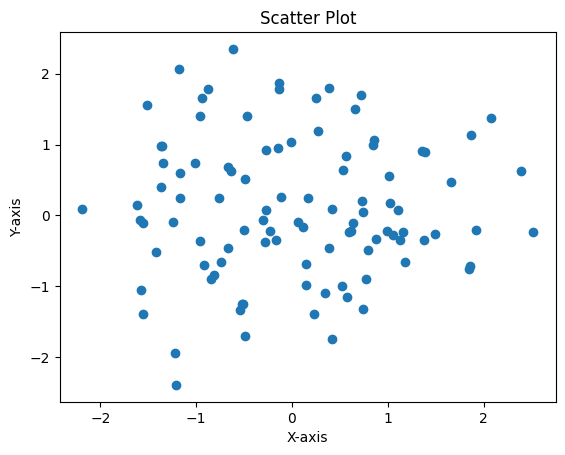

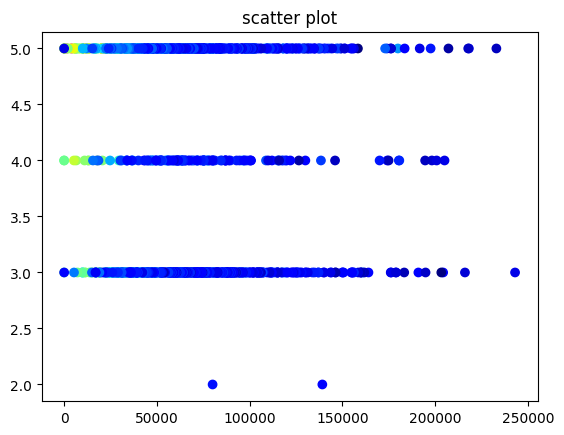


Hill Climbing Optimization:
Iteration 1: x = 0.1000, f(x) = 4.9900
Iteration 2: x = 0.1000, f(x) = 4.9900
Iteration 3: x = 0.1000, f(x) = 4.9900
Iteration 4: x = 0.0761, f(x) = 4.9942
Iteration 5: x = 0.0398, f(x) = 4.9984

Final Solution:
x = 0.0349, f(x) = 4.9988


In [ ]:
# -------------------------------
# Scatter Plot 
# -------------------------------

import numpy as np
import matplotlib.pyplot as plt

def scatter_plot():
    x = np.random.randn(100)
    y = np.random.randn(100)

    plt.scatter(x, y)
    plt.title("Scatter Plot")
    plt.show()

scatter_plot()

# ------------------------------------------------------------------

import pandas as pd 
import matplotlib.pyplot as plt 

data = pd.read_csv("ToyotaCorolla.csv") 
x=data['KM'] 
y=data['Doors'] 
plt.scatter(x,y,c=data['Price'],cmap="jet") 
plt.title("scatter plot") 
plt.show()



# -------------------------------
# Hill Climbing Algorithm
# -------------------------------

import random

def objective_function(x):
    # Goal: maximize -x^2 + 5 (i.e., peak at x = 0)
    return -x**2 + 5

def hill_climbing(start_x, step_size, max_iterations):
    current_x = start_x
    current_score = objective_function(current_x)

    print("\nHill Climbing Optimization:")
    for i in range(max_iterations):
        new_x = current_x + random.uniform(-step_size, step_size)
        new_score = objective_function(new_x)

        print(f"Iteration {i+1}: x = {current_x:.4f}, f(x) = {current_score:.4f}")

        if new_score > current_score:
            current_x = new_x
            current_score = new_score

    print("\nFinal Solution:")
    print(f"x = {current_x:.4f}, f(x) = {current_score:.4f}")

hill_climbing(start_x=0.1, step_size=0.05, max_iterations=5)


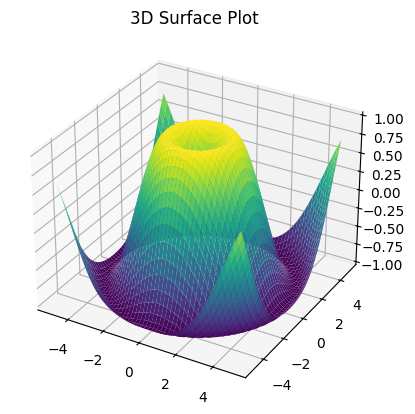

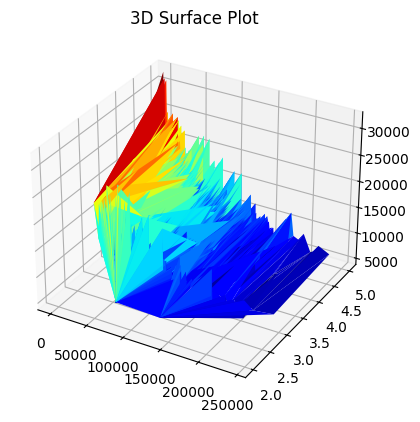

Best First Search Path: A -> C -> D


In [2]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------
# 3D Surface Plot 
# -------------------------------
def plot_3d():
    x = np.linspace(-5, 5, 50)
    y = np.linspace(-5, 5, 50)
    X, Y = np.meshgrid(x, y)
    Z = np.sin(np.sqrt(X**2 + Y**2))

    ax = plt.figure().add_subplot(111, projection='3d')
    ax.plot_surface(X, Y, Z, cmap='viridis')
    ax.set_title("3D Surface Plot")
    plt.show()

plot_3d()


import pandas as pd 
import matplotlib.pyplot as plt 

data = pd.read_csv("ToyotaCorolla.csv") 

x = data['KM'] 
y = data['Doors'] 
z = data['Price'] 
ax = plt.axes(projection='3d') 
ax.plot_trisurf(x,y,z,cmap="jet") 
ax.set_title("3D Surface Plot") 
 
plt.show() 




# ---------------------------------
# Best First Search (Greedy BFS)
# ---------------------------------

from queue import PriorityQueue

def best_first_search(graph, heuristics, start, goal):
    visited = set()
    pq = PriorityQueue()
    pq.put((heuristics[start], start))
    came_from = {}

    while not pq.empty():
        _, current = pq.get()

        if current == goal:
            # Reconstruct path
            path = [goal]
            while current in came_from:
                current = came_from[current]
                path.append(current)
            path.reverse()
            print("Best First Search Path:", ' -> '.join(path))
            return

        if current not in visited:
            visited.add(current)
            for neighbor in graph.get(current, []):
                if neighbor not in visited:
                    pq.put((heuristics[neighbor], neighbor))
                    came_from[neighbor] = current

# Sample graph and heuristic
graph = {
    'A': ['B', 'C'],
    'B': ['D'],
    'C': ['D'],
    'D': []
}
heuristics = {
    'A': 3,
    'B': 2,
    'C': 1,
    'D': 0
}

best_first_search(graph, heuristics, 'A', 'D')


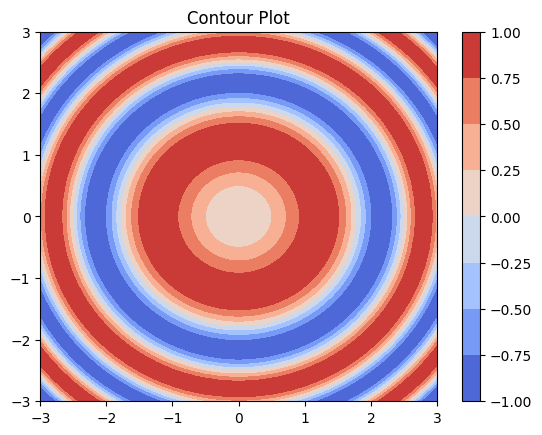

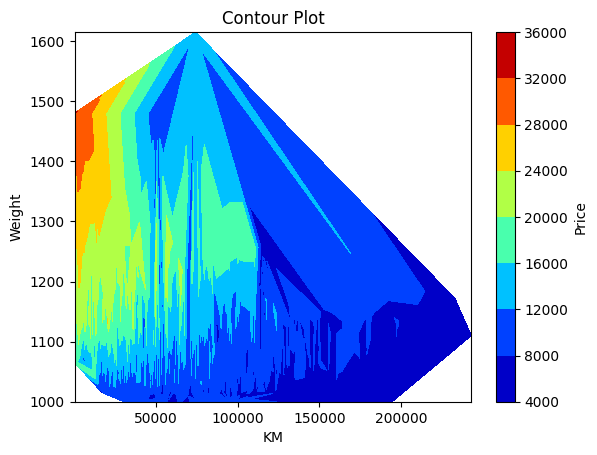

Shortest Path: A -> B -> D


In [23]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------
# Contour Plot 
# -------------------------------
def counter_plot():
    x = np.linspace(-3, 3, 100)
    y = np.linspace(-3, 3, 100)
    X, Y = np.meshgrid(x, y)
    Z = np.sin(X**2 + Y**2)

    # plt.figure(figsize=(6, 5))
    contour = plt.contourf(X, Y, Z, cmap='coolwarm')
    plt.colorbar(contour)
    plt.title("Contour Plot")
    plt.show()

counter_plot()

# --------------------------------------------------------

import pandas as pd 
import matplotlib.pyplot as plt 

data = pd.read_csv("ToyotaCorolla.csv") 
x = data['KM'] 
y = data['Weight'] 
z = data['Price'] 
plt.tricontourf(x, y, z, cmap='jet') 
plt.colorbar(label='Price') 
plt.xlabel('KM') 
plt.ylabel('Weight') 
plt.title('Contour Plot') 
plt.show()


# -------------------------------
# Write a program to implement the A* algorithm.
# -------------------------------

from queue import PriorityQueue

def a_star(graph, heuristics, start, goal):
    pq = PriorityQueue()
    pq.put((heuristics[start], start))
    
    g_cost = {node: float('inf') for node in graph}
    g_cost[start] = 0
    came_from = {}

    while not pq.empty():
        _, current = pq.get()

        if current == goal:
            # Reconstruct path
            path = [goal]
            while current in came_from:
                current = came_from[current]
                path.append(current)
            path.reverse()
            print("Shortest Path:", ' -> '.join(path))
            return

        for neighbor, cost in graph[current]:
            new_cost = g_cost[current] + cost
            if new_cost < g_cost[neighbor]:
                g_cost[neighbor] = new_cost
                priority = new_cost + heuristics[neighbor]
                pq.put((priority, neighbor))
                came_from[neighbor] = current

# Example Graph
graph = {
    'A': [('B', 1), ('C', 3)],
    'B': [('D', 3)],
    'C': [('D', 1)],
    'D': []
}
heuristics = {'A': 4, 'B': 2, 'C': 2, 'D': 0}

# Run A*
a_star(graph, heuristics, 'A', 'D')



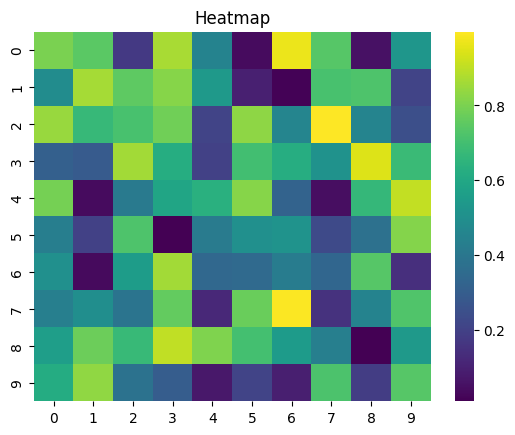

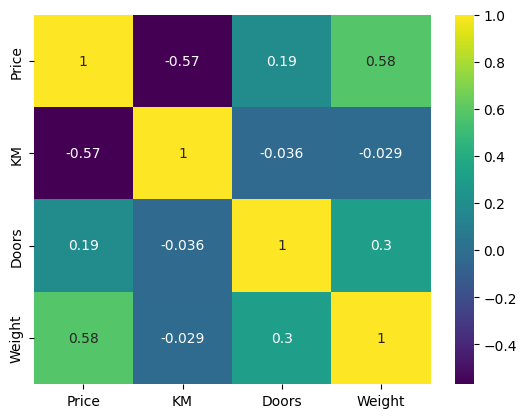

Minimax Optimal Value: 5


In [25]:
# Heat map

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def heat_map():
    data = np.random.rand(10, 10)
    sns.heatmap(data, cmap='viridis')
    plt.title("Heatmap")
    plt.show()

heat_map()

# ---------------------------------------------------------

import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
data = pd.read_csv("ToyotaCorolla.csv") 
sns.heatmap(data[["Price","KM","Doors", "Weight"]].corr(),cmap='viridis',annot=True) 
plt.show()

# ------------------------------------------------------------

# Min max algorithm

def minimax(depth, index, is_max, scores, max_depth):
    if depth == max_depth:
        return scores[index]
    left = minimax(depth + 1, index * 2, not is_max, scores, max_depth)
    right = minimax(depth + 1, index * 2 + 1, not is_max, scores, max_depth)
    return max(left, right) if is_max else min(left, right)

# Example input: depth 3 (8 leaves)
scores = [3, 5, 6, 9, 1, 2, 0, -1]
depth = 3

print("Minimax Optimal Value:", minimax(0, 0, True, scores, depth))

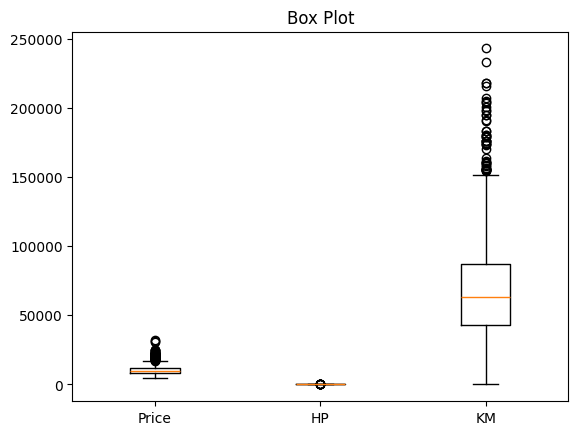

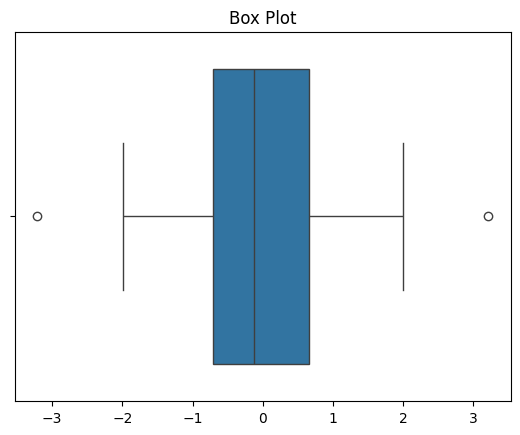

Alpha-Beta Optimal Value: 5


In [3]:
# Box plot

import pandas as pd 
import matplotlib.pyplot as plt 

data = pd.read_csv("ToyotaCorolla.csv") 
plt.title('Box Plot') 
plt.boxplot([data["Price"],data["HP"],data["KM"]]) 
plt.xticks([1,2,3],["Price","HP","KM"]) 
plt.show()


# -------------------------------
# Box Plot
# -------------------------------

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def box_plot():
    x = np.random.randn(100)
    sns.boxplot(x=x)
    plt.title("Box Plot")
    plt.show()

box_plot()



# -------------------------------
# Write a program to implement Alpha-Beta pruning algorithm.
# -------------------------------

def alphabeta(depth, index, is_max, scores, max_depth, alpha, beta):
    if depth == max_depth:
        return scores[index]

    for i in range(2):
        val = alphabeta(depth + 1, index * 2 + i, not is_max, scores, max_depth, alpha, beta)
        if is_max:
            alpha = max(alpha, val)
        else:
            beta = min(beta, val)
        if beta <= alpha:
            break
    return alpha if is_max else beta

# Example input
scores = [3, 5, 6, 9, 1, 2, 0, -1]
depth = 3

# Run Alpha-Beta pruning
result = alphabeta(0, 0, True, scores, depth, float('-inf'), float('inf'))
print("Alpha-Beta Optimal Value:", result)


